In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

import datajoint as dj
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Test classifier by comparing to all-GCL data

Batch effects are expected, but they shouldn't be too large

## Load Baden 16 data

In [ ]:
data_dir = '../data'  # /gpfs01/euler/data/Resources/Classifier_v2

chirp_feats_file = os.path.join(data_dir, 'chirp_feats.npz')
bar_feats_file = os.path.join(data_dir, 'bar_feats.npz')
baden_data_file = os.path.join(data_dir, 'RGCData_postprocessed.mat')

In [ ]:
from rgc_classifier.baden16 import load_baden_data

chirp_feats = np.load(chirp_feats_file)
bar_feats = np.load(bar_feats_file)
data_16 = load_baden_data(baden_data_file)
data_16.keys()

In [ ]:
from rgc_classifier.classifier import extract_features

X_16, feature_names = extract_features(
    preproc_chirps=data_16['chirp_traces'],
    preproc_bars=data_16['bar_traces'],
    bar_ds_pvalues=data_16['bar_dp'],
    roi_size_um2s=data_16['roi_size_um2'],
    chirp_features=chirp_feats,
    bar_features=bar_feats,
)

## Prepare dj config

In [154]:
username = !whoami
username = username[0]
username

'joesterle'

In [155]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/berens/user/joesterle'

In [156]:
# Set config file
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [157]:
schema_name = f"ageuler_all_rgcs"

In [158]:
output_folder = f'/gpfs01/euler/data/SharedFiles/projects/all-GCL/datajoint/classifier'
assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [159]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier

prepare_dj_config_rgc_classifier(output_folder,
                                 input_folder="/gpfs01/euler/data/Resources/Classifier/rgc_classifier_v2")

print("schema_name:", dj.config['schema_name'])
dj.conn()

schema_name: ageuler_all_rgcs


DataJoint connection (disconnected) joesterle@172.25.240.200:3306

In [160]:
from djimaging.user.all_rgcs.schemas.all_rgcs_schema import *

In [161]:
from djimaging.utils.dj_utils import activate_schema

try:
    if Repository(djimaging_src_path).head.shorthand not in accepted_branches:
        raise ValueError(Repository(djimaging_src_path).head.shorthand)
except Exception as e:
    print(e)

activate_schema(schema=schema, create_schema=False, create_tables=False)
schema

[2025-08-12 10:50:48,856][WARNING]: MySQL server has gone away. Reconnecting to the server.


name 'Repository' is not defined


Schema `ageuler_all_rgcs`

## Get new data

In [165]:
# Restrict to HQ, ventral ROIs

experimenter_25, preproc_chirps_25, preproc_bars_25, bar_dps_25, roi_size_um2s_25 = (
        ((Baden16TracesV2() & ["cond1='C1'", "cond1='c1'", "cond1='control'"])
         & (Experiment.Animal() & "genline='Bl6'")
         & [(ChirpQI() & "qidx>0.45").proj(), (OsDsIndexes() & "d_qi>0.6").proj()]
         & (RetinalRoiLocation & "ventral_dorsal_pos_um<-200 and ventral_dorsal_pos_um>-1300").proj())
        * Roi().proj('roi_size_um2')
).fetch('experimenter',
        'preproc_chirp',
        'preproc_bar', 'ds_pvalue',
        'roi_size_um2')

In [172]:
preproc_chirps_25 = np.vstack(preproc_chirps_25)
preproc_bars_25 = np.vstack(preproc_bars_25)

In [ ]:
X_25, _ = extract_features(
    preproc_chirps=preproc_chirps_25, preproc_bars=preproc_bars_25, bar_ds_pvalues=bar_dps_25,
    roi_size_um2s=roi_size_um2s_25, chirp_features=chirp_feats, bar_features=bar_feats)

In [174]:
X_combo = np.vstack([X_16, X_25])
dataset_combo = ['16'] * X_16.shape[0] + ['v2'] * X_25.shape[0]

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_combo_scaled = scaler.fit_transform(X_combo)

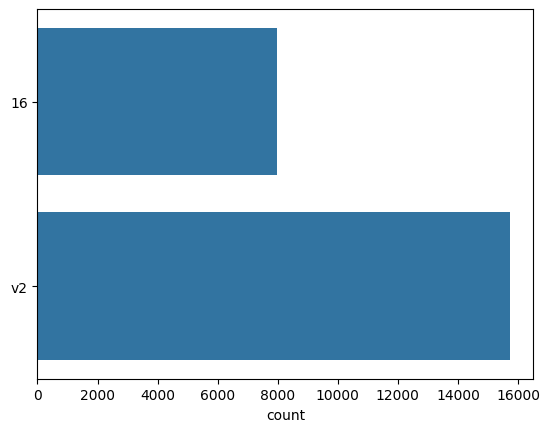

In [176]:
sns.countplot(dataset_combo)
plt.show()

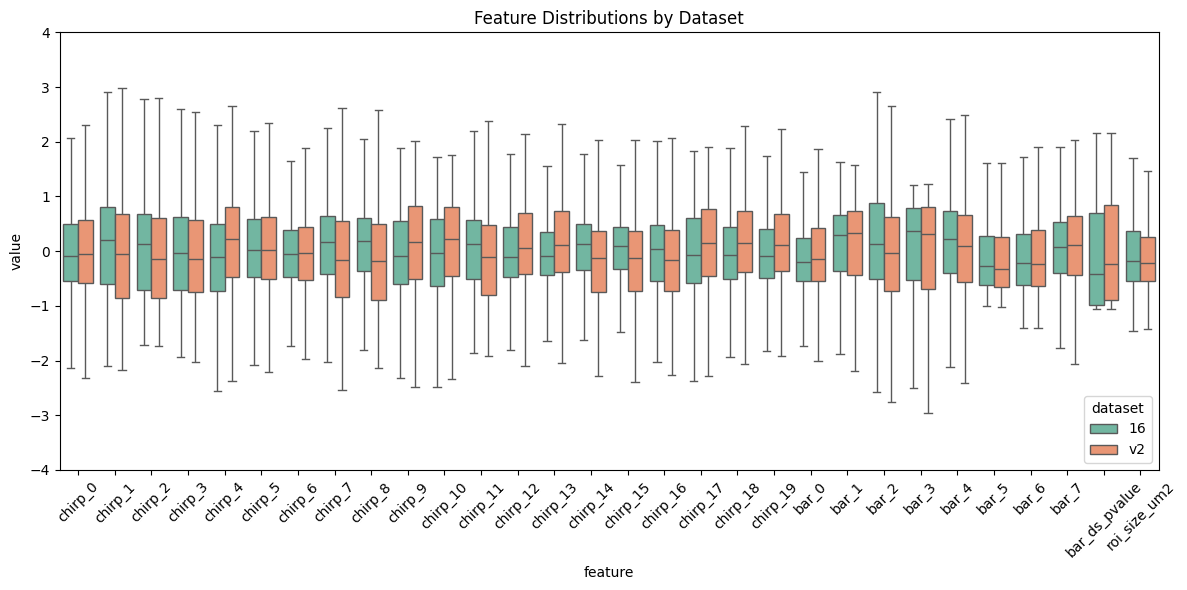

In [177]:
df = pd.DataFrame(X_combo_scaled, columns=feature_names)
df['dataset'] = dataset_combo

df_melt = df.melt(id_vars='dataset', var_name='feature', value_name='value')

plt.figure(figsize=(12, 6))
sns.boxplot(x='feature', y='value', hue='dataset', data=df_melt, fliersize=0, palette='Set2')
plt.title('Feature Distributions by Dataset')
plt.xticks(rotation=45)
plt.ylim(-4, +4)
plt.tight_layout()
plt.show()

In [84]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
X_combo_tsne = tsne.fit_transform(X_combo_scaled)

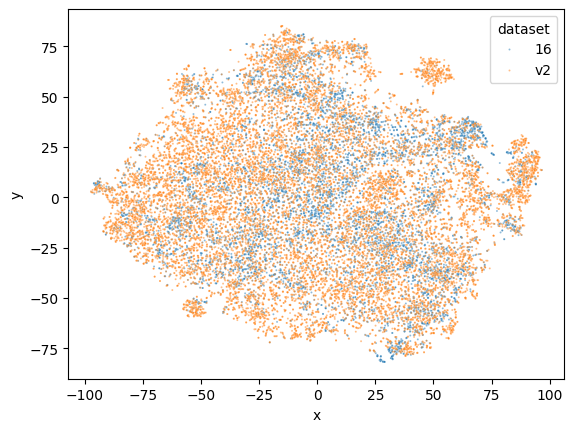

In [85]:
df_combo_tsne = pd.DataFrame({'x': X_combo_tsne[:, 0], 'y': X_combo_tsne[:, 1], 'dataset': dataset_combo})

sns.scatterplot(data=df_combo_tsne, x='x', y='y', hue='dataset', alpha=0.5, s=2)
plt.show()

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


def check_back_effects(X, y, feature_names=None):
    """
    Analyze feature importance using Random Forest classifier
    
    Parameters:
    X: Feature matrix
    y: Target variable
    feature_names: List of feature names (optional)
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train Random Forest classifier
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
    )
    clf.fit(X_train, y_train)

    # Make predictions and evaluate
    y_pred = clf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Feature importance analysis
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]  # sort descending

    # Create feature importance plot
    plt.figure(figsize=(12, 6))
    plt.title("Feature Importance")

    # Use feature names if provided, otherwise use indices
    if feature_names is not None:
        labels = [feature_names[i] for i in indices]
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), labels, rotation=45, ha='right')
    else:
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), [f'Feature {i}' for i in indices], rotation=45, ha='right')

    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.tight_layout()
    plt.show()

Accuracy: 0.7737241670181358

Classification Report:
               precision    recall  f1-score   support

          16       0.75      0.49      0.59      1596
          v2       0.78      0.92      0.84      3146

    accuracy                           0.77      4742
   macro avg       0.77      0.70      0.72      4742
weighted avg       0.77      0.77      0.76      4742



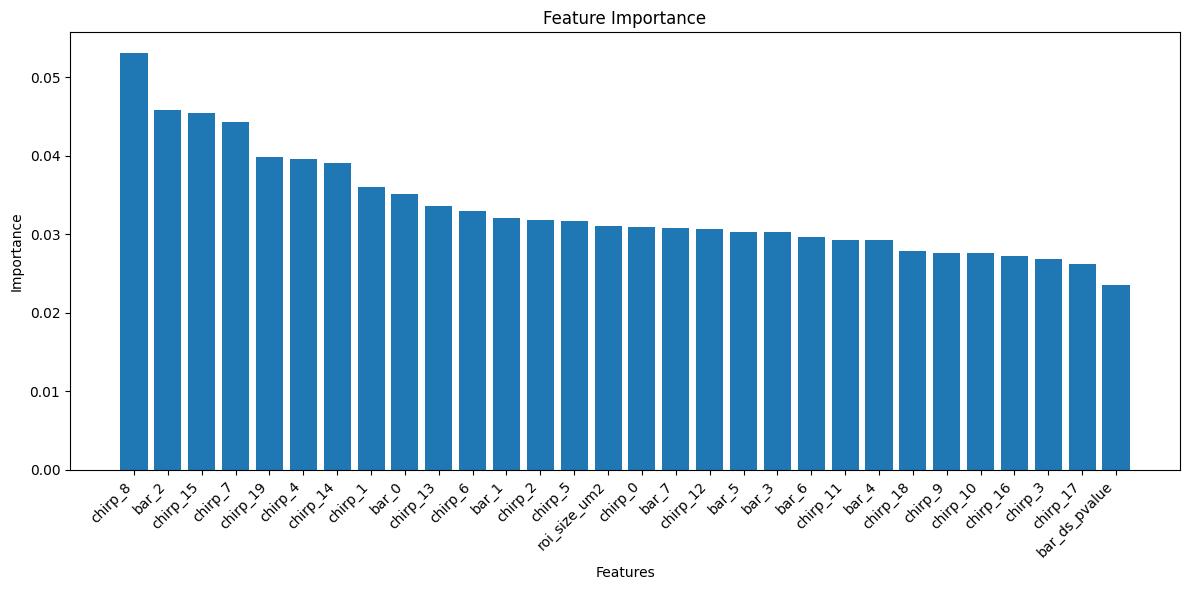

In [179]:
check_back_effects(X=X_combo, y=dataset_combo, feature_names=feature_names)

['Arlinghaus' 'Cai' 'Debinski' 'Dyszkant' 'Franke' 'Gonschorek'
 'Schwerd-Kleine' 'Szatko']


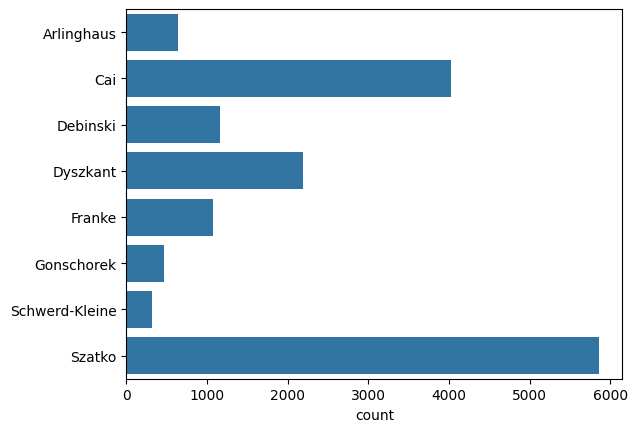

In [182]:
sns.countplot(experimenter_25);
print(np.unique(experimenter_25))

Accuracy: 0.7491148204350025

Classification Report:
               precision    recall  f1-score   support

         Cai       0.76      0.56      0.65       805
      Szatko       0.75      0.88      0.81      1172

    accuracy                           0.75      1977
   macro avg       0.75      0.72      0.73      1977
weighted avg       0.75      0.75      0.74      1977



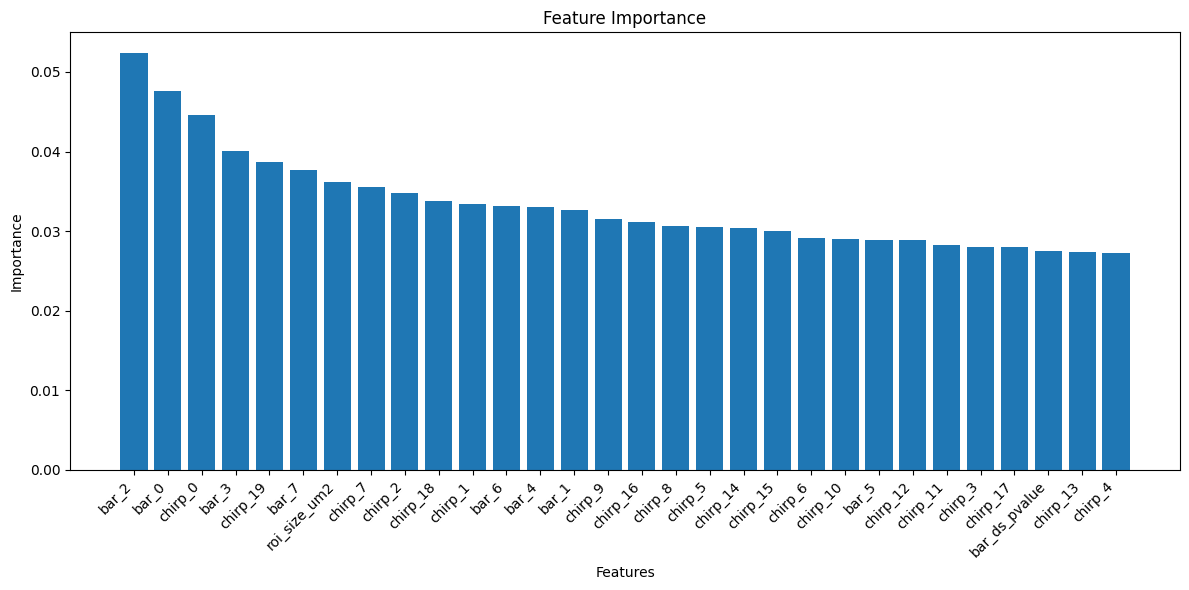

In [180]:
idxs = (experimenter_25 == 'Szatko') | (experimenter_25 == 'Cai')
check_back_effects(X=X_25[idxs], y=experimenter_25[idxs], feature_names=feature_names)

Accuracy: 0.7683109118086696

Classification Report:
               precision    recall  f1-score   support

    Debinski       0.76      0.48      0.59       231
    Dyszkant       0.77      0.92      0.84       438

    accuracy                           0.77       669
   macro avg       0.77      0.70      0.71       669
weighted avg       0.77      0.77      0.75       669



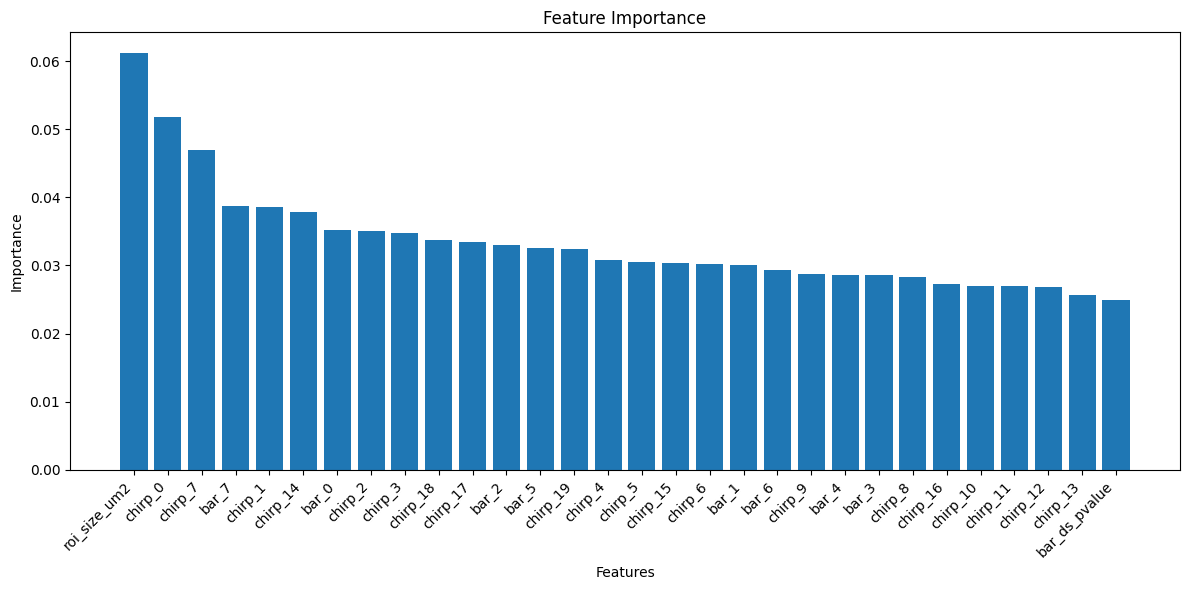

In [183]:
idxs = (experimenter_25 == 'Dyszkant') | (experimenter_25 == 'Debinski')
check_back_effects(X=X_25[idxs], y=experimenter_25[idxs], feature_names=feature_names)

While batch effects are quite strong, they are quite strong across all experimenter comparisons.  
The Baden 16 dataset does not seem to be much different from any other dataset.